### **Exploratory Data Analysis (EDA)**

This notebook explores the AQI dataset to understand data patterns and relationships affecting air quality.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Data Overview

In [ ]:
data = pd.read_csv("/content/delhi-weather-aqi-2025.csv")
data.head()

,date_ist,time_ist,location,lat,lon,temp_c,humidity,pressure_mb,windspeed_kph,condition_text,description,aqi_index,pm2_5,pm10,co,no2
0,01/01/2025,0:00,Anand Vihar,28.6469,77.316,8.1,100,995.4,2.9,Mainly clear,WMO Code 1,197,185.8,188.6,1907,56.7
1,01/01/2025,1:00,Anand Vihar,28.6469,77.316,7.7,100,994.7,3.2,Overcast,WMO Code 3,198,174.6,177.4,1669,44.8
2,01/01/2025,2:00,Anand Vihar,28.6469,77.316,7.5,100,994.3,4.5,Overcast,WMO Code 3,199,164.4,166.7,1493,34.6
3,01/01/2025,3:00,Anand Vihar,28.6469,77.316,7.8,99,994.1,6.0,Overcast,WMO Code 3,200,156.5,158.8,1401,26.7
4,01/01/2025,4:00,Anand Vihar,28.6469,77.316,7.3,100,993.8,6.8,Overcast,WMO Code 3,200,149.5,151.8,1372,20.6


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52560 entries, 0 to 52559
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date_ist        52560 non-null  object 
 1   time_ist        52560 non-null  object 
 2   location        52560 non-null  object 
 3   lat             52560 non-null  float64
 4   lon             52560 non-null  float64
 5   temp_c          52560 non-null  float64
 6   humidity        52560 non-null  int64  
 7   pressure_mb     52560 non-null  float64
 8   windspeed_kph   52560 non-null  float64
 9   condition_text  52560 non-null  object 
 10  description     52560 non-null  object 
 11  aqi_index       52560 non-null  int64  
 12  pm2_5           52560 non-null  float64
 13  pm10            52560 non-null  float64
 14  co              52560 non-null  int64  
 15  no2             52560 non-null  float64
dtypes: float64(8), int64(3), object(5)
memory usage: 6.4+ MB


In [ ]:
data.describe()

,lat,lon,temp_c,humidity,pressure_mb,windspeed_kph,aqi_index,pm2_5,pm10,co,no2
count,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000
mean,28.608850,77.174567,25.024406,62.285940,983.162635,6.565820,287.364212,89.542432,300.462700,863.844273,35.442757
std,0.058927,0.096519,7.618231,23.454666,6.688582,3.478066,327.979524,55.363812,412.782899,600.845140,28.978905
min,28.527300,77.049400,5.700000,5.000000,966.100000,0.000000,56.000000,6.000000,6.100000,146.000000,1.700000
25%,28.556200,77.100000,19.500000,44.000000,977.500000,4.000000,152.000000,51.100000,80.600000,464.000000,14.900000
50%,28.609300,77.160100,26.500000,65.000000,983.400000,6.000000,170.000000,76.400000,151.800000,664.000000,26.900000
75%,28.646900,77.261800,30.500000,82.000000,988.900000,8.700000,238.000000,110.400000,325.000000,1078.000000,47.100000
max,28.704100,77.316000,43.800000,100.000000,998.800000,27.100000,2742.000000,443.300000,3263.400000,7432.000000,220.100000


In [ ]:
data.isnull().sum()

,0
date_ist,0
time_ist,0
location,0
lat,0
lon,0
temp_c,0
humidity,0
pressure_mb,0
windspeed_kph,0
condition_text,0


### Univariate Analysis

In [ ]:
data.dtypes

,0
date_ist,object
time_ist,object
location,object
lat,float64
lon,float64
temp_c,float64
humidity,int64
pressure_mb,float64
windspeed_kph,float64
condition_text,object


In [ ]:
### Identifying Numerical and Categorical Features
num_cols = data.select_dtypes(include=['int64','float64']).columns
cat_cols = data.select_dtypes(include=['object']).columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)


Numerical Columns: Index(['lat', 'lon', 'temp_c', 'humidity', 'pressure_mb', 'windspeed_kph',
       'aqi_index', 'pm2_5', 'pm10', 'co', 'no2'],
      dtype='object')
Categorical Columns: Index(['date_ist', 'time_ist', 'location', 'condition_text', 'description'], dtype='object')


In [ ]:
data[num_cols].describe()

,lat,lon,temp_c,humidity,pressure_mb,windspeed_kph,aqi_index,pm2_5,pm10,co,no2
count,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000
mean,28.608850,77.174567,25.024406,62.285940,983.162635,6.565820,287.364212,89.542432,300.462700,863.844273,35.442757
std,0.058927,0.096519,7.618231,23.454666,6.688582,3.478066,327.979524,55.363812,412.782899,600.845140,28.978905
min,28.527300,77.049400,5.700000,5.000000,966.100000,0.000000,56.000000,6.000000,6.100000,146.000000,1.700000
25%,28.556200,77.100000,19.500000,44.000000,977.500000,4.000000,152.000000,51.100000,80.600000,464.000000,14.900000
50%,28.609300,77.160100,26.500000,65.000000,983.400000,6.000000,170.000000,76.400000,151.800000,664.000000,26.900000
75%,28.646900,77.261800,30.500000,82.000000,988.900000,8.700000,238.000000,110.400000,325.000000,1078.000000,47.100000
max,28.704100,77.316000,43.800000,100.000000,998.800000,27.100000,2742.000000,443.300000,3263.400000,7432.000000,220.100000


In [ ]:
cols = num_cols.drop(['lat','lon'])
# Latitude and longitude are numerical but represent spatial coordinates,
# so they are excluded from detailed distribution analysis

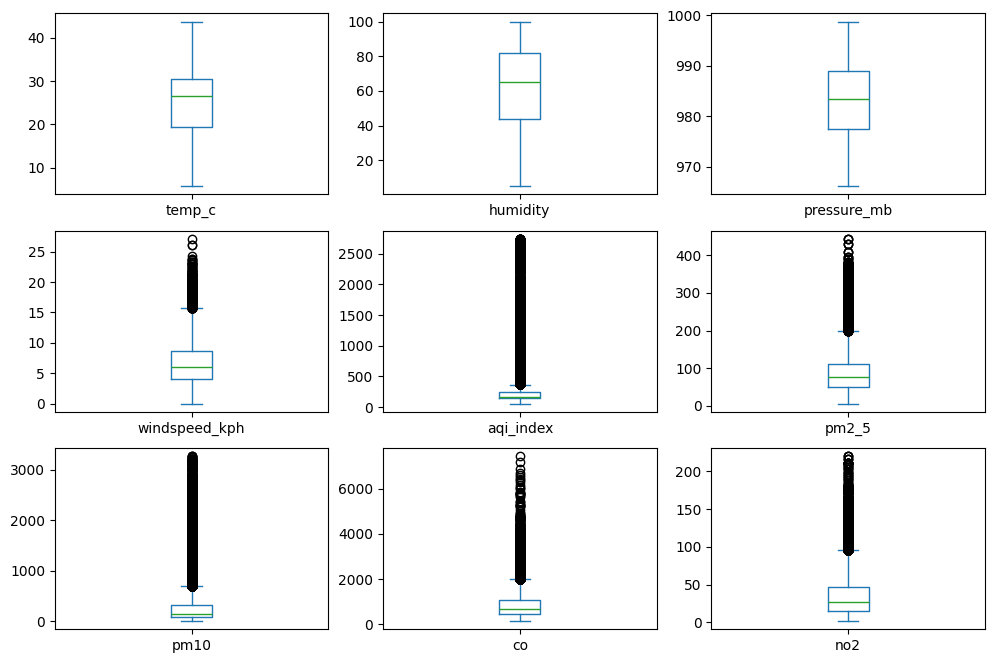

In [ ]:
data[cols].plot(kind='box', subplots=True, layout=(3,3), figsize=(12,8))
plt.show()

From the boxplots, variables such as temperature, humidity, and pressure: appear stable with fewer outliers.

However, pollution-related variables like AQI, PM2.5, PM10, CO, and NO2 : showing a large number of outliers, indicating high variability and extreme pollution levels.

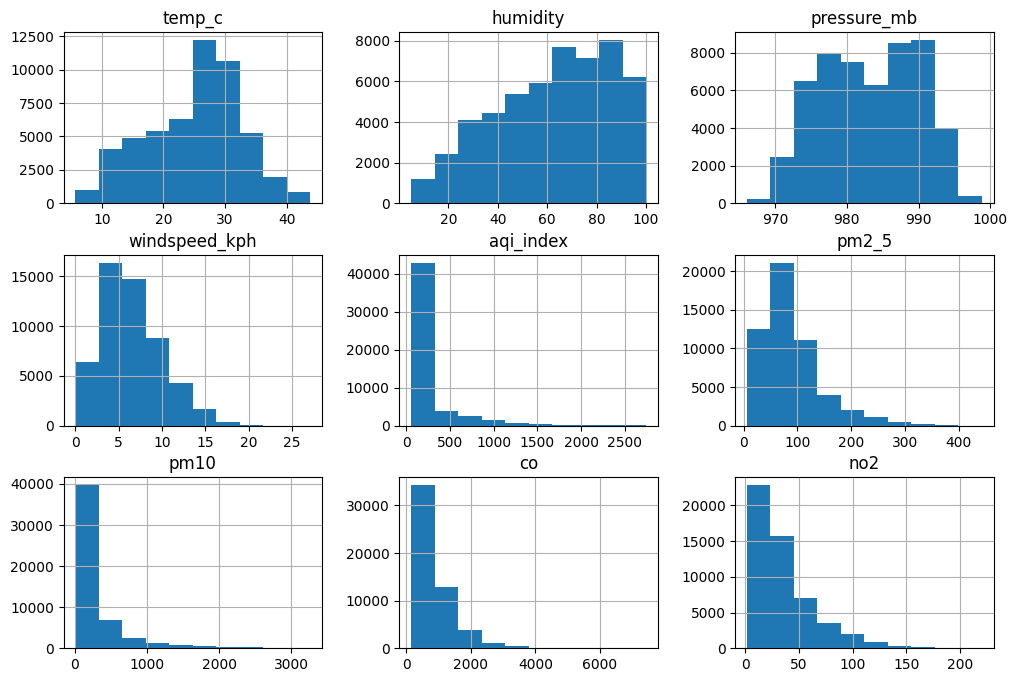

In [ ]:
data[cols].hist(figsize=(12,8))
plt.show()

Pollutant variables show right-skewed distributions, indicating the presence of higher extreme values.


In [ ]:
cat_cols

Index(['date_ist', 'time_ist', 'location', 'condition_text', 'description'], dtype='object')

In [ ]:
data['date_ist'] = pd.to_datetime(data['date_ist'], dayfirst=True)

In [ ]:
data['time_ist'] = pd.to_datetime(data['time_ist'], format='%H:%M').dt.hour

In [ ]:
cat_cols = data.select_dtypes(include=['object']).columns
cat_cols

Index(['location', 'condition_text', 'description'], dtype='object')

In [ ]:
data['condition_text']

,condition_text
0,Mainly clear
1,Overcast
2,Overcast
3,Overcast
4,Overcast
...,...
52555,Mainly clear
52556,Partly cloudy
52557,Partly cloudy
52558,Overcast


In [ ]:
data['condition_text'].value_counts()

,count
condition_text,
Clear sky,30086
Overcast,10285
Mainly clear,4444
Drizzle: Light,3090
Partly cloudy,2557
Drizzle: Moderate,643
Rain: Moderate,421
Rain: Slight,416
Fog,334


In [ ]:
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(data[col].value_counts())


--- location ---
location
Anand Vihar        8760
Connaught Place    8760
Dwarka             8760
Okhla Phase III    8760
Rohini             8760
IGI Airport        8760
Name: count, dtype: int64

--- condition_text ---
condition_text
Clear sky            30086
Overcast             10285
Mainly clear          4444
Drizzle: Light        3090
Partly cloudy         2557
Drizzle: Moderate      643
Rain: Moderate         421
Rain: Slight           416
Fog                    334
Drizzle: Dense         221
Rain: Heavy             63
Name: count, dtype: int64

--- description ---
description
WMO Code 0     30086
WMO Code 3     10285
WMO Code 1      4444
WMO Code 51     3090
WMO Code 2      2557
WMO Code 53      643
WMO Code 63      421
WMO Code 61      416
WMO Code 45      334
WMO Code 55      221
WMO Code 65       63
Name: count, dtype: int64


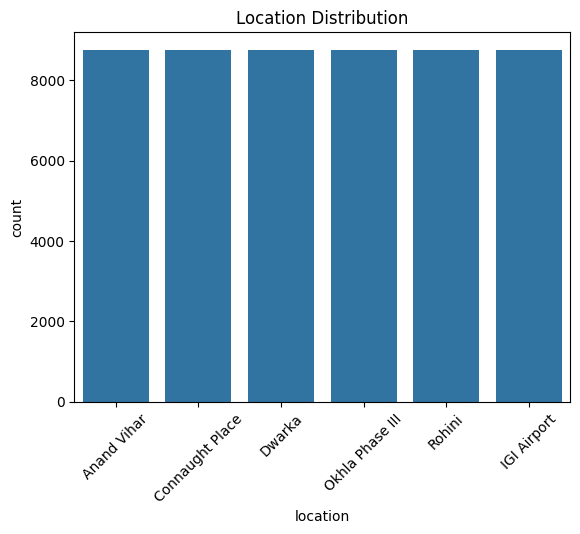

In [ ]:
sns.countplot(x=data['location'])
plt.title('Location Distribution')
plt.xticks(rotation=45)
plt.show()

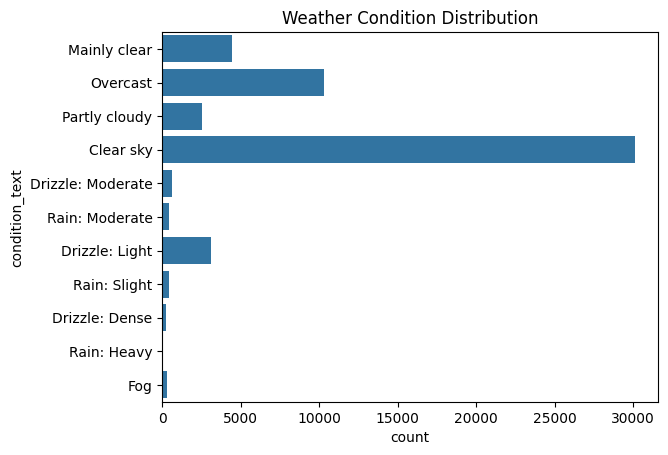

In [ ]:
sns.countplot(y=data['condition_text'])
plt.title('Weather Condition Distribution')
plt.show()

### Bivariate Analysis

In [ ]:
num_cols

Index(['lat', 'lon', 'temp_c', 'humidity', 'pressure_mb', 'windspeed_kph',
       'aqi_index', 'pm2_5', 'pm10', 'co', 'no2'],
      dtype='object')

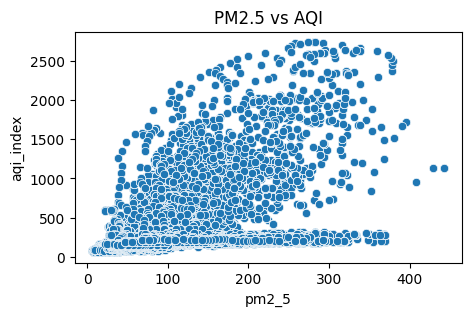

In [ ]:
plt.figure(figsize=(5,3))
sns.scatterplot(x=data['pm2_5'], y=data['aqi_index'])
plt.title('PM2.5 vs AQI')
plt.show()

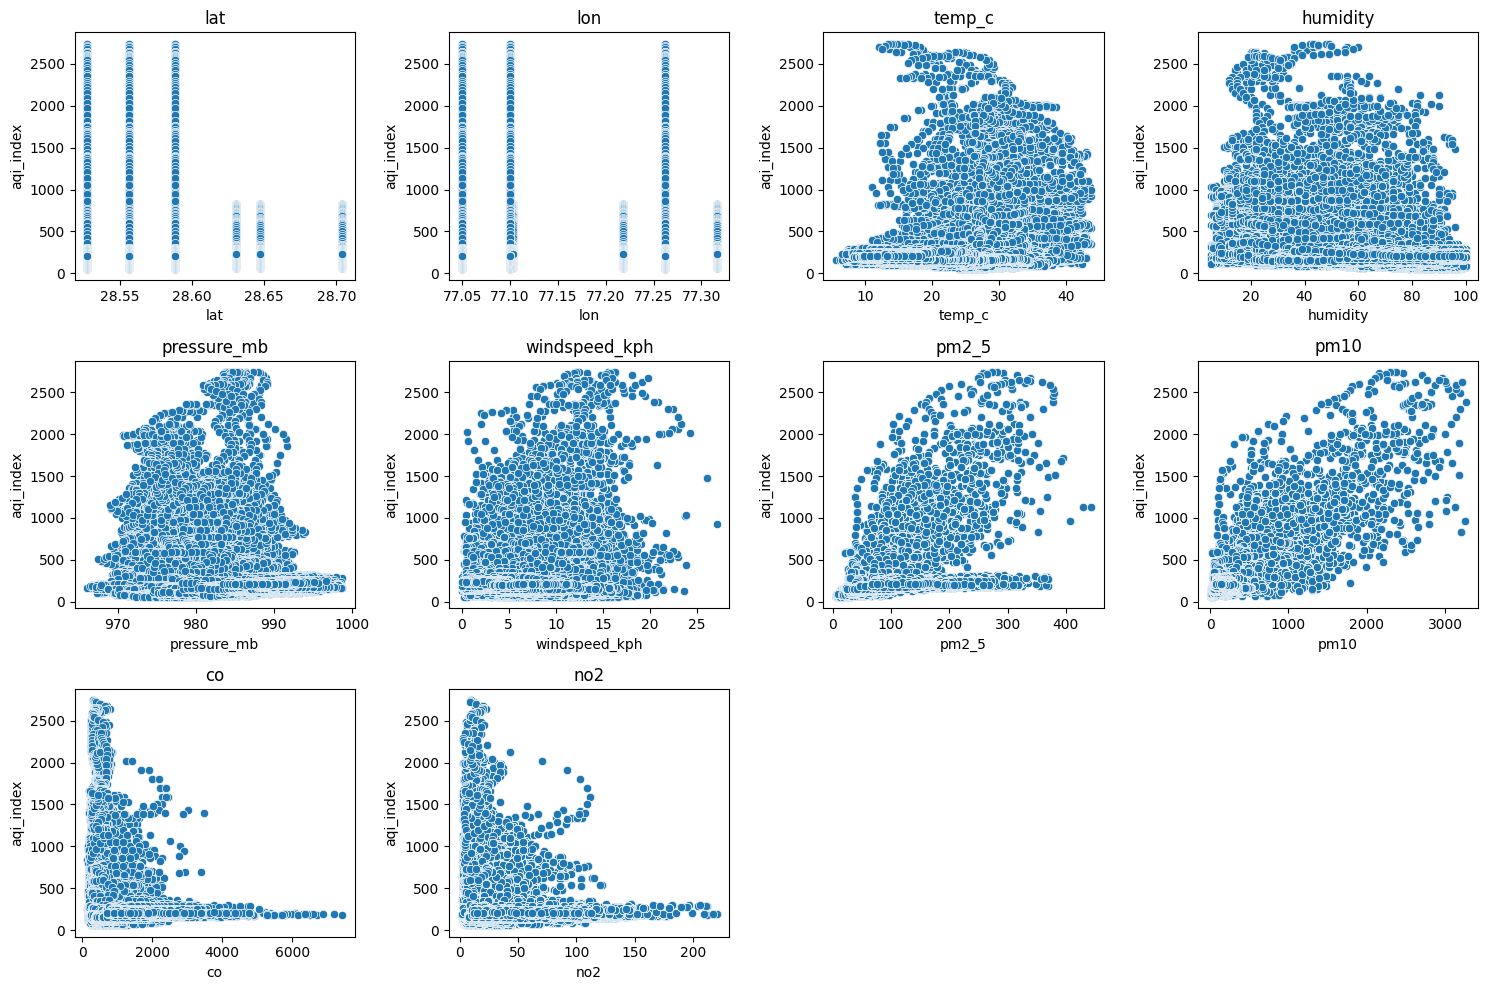

In [ ]:
## numeric
cols = [c for c in num_cols if c != 'aqi_index']

plt.figure(figsize=(15,10))

for i, col in enumerate(cols):
    plt.subplot(3, 4, i+1)
    sns.scatterplot(x=data[col], y=data['aqi_index'])
    plt.title(col)

plt.tight_layout()
plt.show()

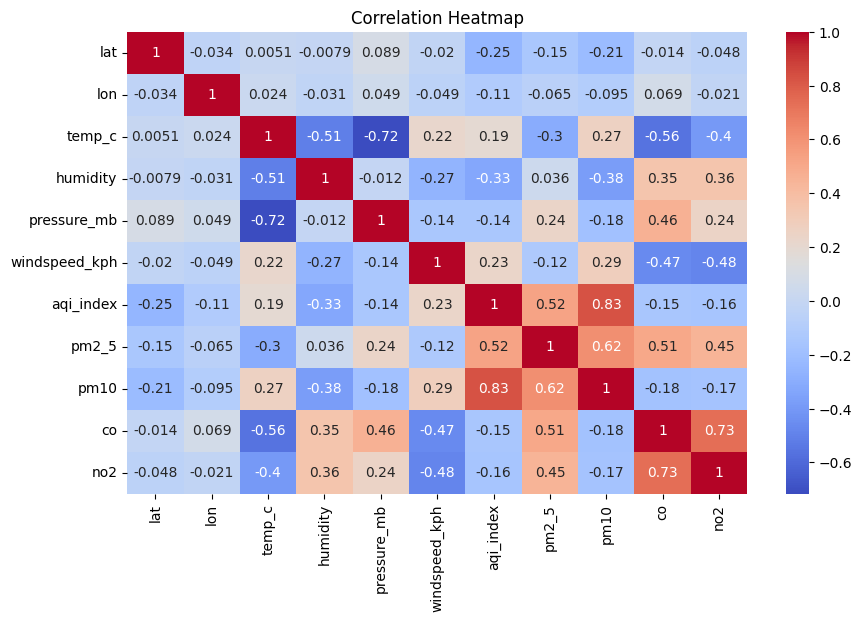

In [ ]:
## Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(data[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

- Pollutants PM2.5 and PM10 show strong positive correlation with AQI.
- CO and NO2 show strong correlation with each other, indicating similar pollution sources.NO2 shows weak correlation with AQI in this dataset.

- Weather-related features like temperature and humidity show weak correlation.

In [ ]:
cat_cols

Index(['location', 'condition_text', 'description'], dtype='object')

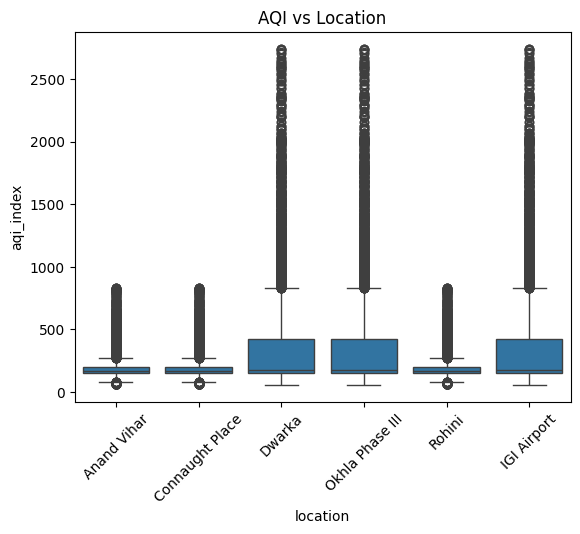

In [ ]:
sns.boxplot(x=data['location'], y=data['aqi_index'])
plt.title('AQI vs Location')
plt.xticks(rotation=45)
plt.show()

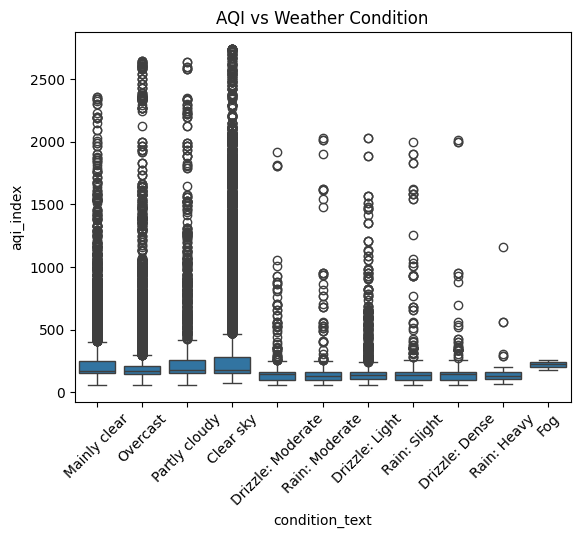

In [ ]:
sns.boxplot(x=data['condition_text'], y=data['aqi_index'])
plt.title('AQI vs Weather Condition')
plt.xticks(rotation=45)
plt.show()

## The variables condition_text and description contain similar information

In [ ]:
data.groupby('condition_text')['aqi_index'].median().sort_values()

,aqi_index
condition_text,
Rain: Moderate,128.0
Rain: Heavy,130.0
Rain: Slight,133.5
Drizzle: Light,135.0
Drizzle: Moderate,142.0
Drizzle: Dense,145.0
Overcast,165.0
Mainly clear,171.0
Partly cloudy,173.0


In [ ]:
print(data['date_ist'].dtype)
print(data['time_ist'].dtype)

datetime64[ns]
int32


In [ ]:
data['month'] = data['date_ist'].dt.month
data['day_name'] = data['date_ist'].dt.day_name()

In [ ]:
data['day_name'].value_counts()

,count
day_name,
Wednesday,7632
Thursday,7488
Friday,7488
Saturday,7488
Sunday,7488
Monday,7488
Tuesday,7488


In [ ]:
data.groupby('day_name')['aqi_index'].mean()

,aqi_index
day_name,
Friday,302.783253
Monday,273.720353
Saturday,305.345353
Sunday,297.137019
Thursday,288.316106
Tuesday,266.469551
Wednesday,277.958726


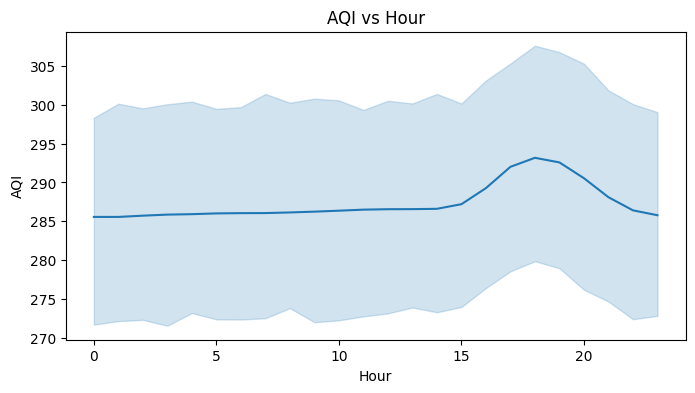

In [ ]:
plt.figure(figsize=(8,4))
sns.lineplot(x='time_ist', y='aqi_index', data=data)
plt.title('AQI vs Hour')
plt.xlabel('Hour')
plt.ylabel('AQI')
plt.show()

In [ ]:
data['month'].value_counts()

,count
month,
1,4464
3,4464
7,4464
5,4464
12,4464
10,4464
8,4464
4,4320
9,4320


In [ ]:
data.groupby('month')['aqi_index'].mean()

,aqi_index
month,
1,189.234543
2,154.921131
3,560.311828
4,541.910417
5,582.764113
6,383.917361
7,147.824597
8,223.970430
9,123.890972


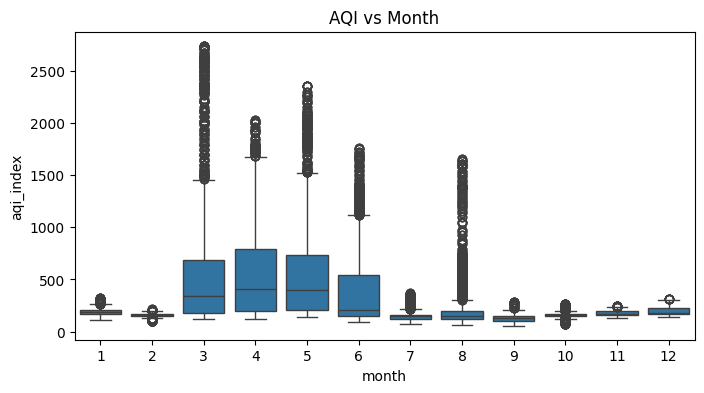

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x='month', y='aqi_index', data=data)
plt.title('AQI vs Month')
plt.show()

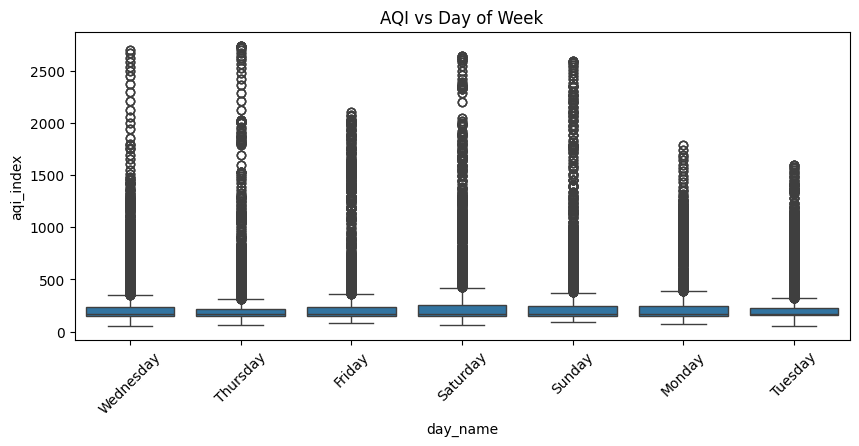

In [ ]:
plt.figure(figsize=(10,4))
sns.boxplot(x='day_name', y='aqi_index', data=data)
plt.title('AQI vs Day of Week')
plt.xticks(rotation=45)
plt.show()

## Key Insights

- PM2.5 and PM10 strongly influence AQI.
- CO and NO2 show related patterns.
- Weather features show weaker relationships with AQI but may still provide useful context.
- AQI varies across time and seasons.
